# Surface Water Fraction Model Training

End-to-end regression pipeline: physics baseline → preprocessing → model selection → feature study → hyperparameter optimisation → explainability → pruning → generalisation → error analysis → final model.

## 1. Initial Setup

Load all required libraries, define canonical constants, register all utility functions, and load the raw dataset. Every downstream section imports variables defined here — nothing is redefined in later sections.

- **Feature sets used:** not yet (constants only)
- **Models used:** not yet (helper definitions only)
- **Why:** centralising setup guarantees reproducibility and avoids silent redefinitions.

In [ ]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
import warnings
import xarray as xr
import xgboost as xgb

from lightgbm import LGBMRegressor
from scipy import stats
from scipy.linalg import LinAlgWarning
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge, ElasticNet

# ── Reproducibility ────────────────────────────────────────────────────
RANDOM_STATE = 42
TARGET_COL = 'fwns'
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
np.random.seed(RANDOM_STATE)

# ── Canonical feature sets ─────────────────────────────────────────────
REFERENCE_FEATURE_SET = [
    'tbtoa19H', 'tran19H', 'tbup19H',
    'tbtoa37H', 'tran37H', 'tbup37H',
    'tbtoa19V', 'tran19V', 'tbup19V',
    'tbtoa37V', 'tran37V', 'tbup37V',
    'surtep_ERA5', 'vsm', 'VOD',
]  # Used as the fixed feature set for preprocessing and model selection studies.

FULL_FEATURE_SET = [
    'tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H',
    'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H',
    'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V',
    'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V',
    'surtep_ERA5', 'vsm', 'VOD', 'Tmn', 'PWV', 'VPD',
    'clase', 'porcentaje clase', 'day', 'latitude_grid', 'longitude_grid']

# ── Model selection study constants ────────────────────────────────────
MODEL_SELECTION_N_TRIALS = 25
MODEL_SELECTION_N_SPLITS = 3
MODEL_SELECTION_SAMPLE_FRAC = 0.3

# ── Full HPO constants ─────────────────────────────────────────────────
TUNING_N_TRIALS = 25
TUNING_EARLY_STOPPING = 50
TUNING_N_SPLITS = 3
TUNING_SAMPLE_FRAC = 0.4

# ── Final CV / pruning constants ───────────────────────────────────────
FINAL_CV_N_SPLITS = 5
RFECV_SAMPLE_FRAC = 0.25
RFECV_TOL = 0.005  # Accept fewest features within 0.5 % relative RMSE of the best CV score
SHAP_THRESHOLD = 0.00125

# ── Directory constants ────────────────────────────────────────────────
HPO_DIR = 'HPO_results'
MODEL_DIR = 'models'

# ── Suppressing warnings ───────────────────────────────────────────────
warnings.filterwarnings('ignore', category=LinAlgWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [ ]:
# ============================================================
# UTILITY FUNCTIONS — do not modify below this line
# ============================================================
def train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models):
    results_all = {}
    iterator = models.items() if isinstance(models, dict) else models

    for name, model in tqdm(iterator, desc='Training models'):
        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        results_all[name] = {
            'MAE_train': mean_absolute_error(y_train, y_pred_train),
            'MSE_train': mean_squared_error(y_train, y_pred_train),
            'R2_train': r2_score(y_train, y_pred_train),
            'MAE_test': mean_absolute_error(y_test, y_pred_test),
            'MSE_test': mean_squared_error(y_test, y_pred_test),
            'R2_test': r2_score(y_test, y_pred_test),
            'time_s': round(elapsed_time, 4),
        }

    return results_all

def preprocess_dataset(df_in, target_col=TARGET_COL, remove_zeros=False, boxcox_target=False, scale_features=False):
    df_out = df_in.copy()
    boxcox_lambda = None

    if remove_zeros:
        df_out = df_out[df_out[target_col] != 0].copy()

    if boxcox_target:
        if (df_out[target_col] <= 0).any():
            raise ValueError('Box-Cox requires strictly positive target values.')
        df_out[target_col], boxcox_lambda = stats.boxcox(df_out[target_col])

    if scale_features:
        feature_cols = df_out.columns.drop(target_col)
        scaler = StandardScaler()
        df_out[feature_cols] = scaler.fit_transform(df_out[feature_cols])

    return df_out, boxcox_lambda

def evaluate_scaling_variants(df_raw, variants, models, target_col=TARGET_COL):
    rows = []

    for variant_name, params in tqdm(variants.items(), desc='Scaling variants'):
        df_variant, lam = preprocess_dataset(df_raw, target_col=target_col, **params)
        y_variant = df_variant[target_col]

        tr_idx, te_idx = train_test_split(
            df_variant.index,
            test_size=0.2,
            random_state=RANDOM_STATE,
            shuffle=True,
        )

        X_train = df_variant.drop(columns=[target_col]).loc[tr_idx]
        X_test = df_variant.drop(columns=[target_col]).loc[te_idx]
        y_train = y_variant.loc[tr_idx]
        y_test = y_variant.loc[te_idx]

        metrics = train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models)

        for model_name, values in metrics.items():
            row = {
                'variant': variant_name,
                'model': model_name,
                'rows': len(df_variant),
                'boxcox_lambda': np.nan if lam is None else lam,
                **values,
            }
            rows.append(row)

    return pd.DataFrame(rows)

def evaluate_feature_sets(df_model, y, train_idx, test_idx, feature_sets, models):
    all_rows = []

    for set_name, features in tqdm(feature_sets.items(), desc='Feature sets'):
        X_train = df_model.loc[train_idx, features]
        X_test = df_model.loc[test_idx, features]
        y_train = y.loc[train_idx]
        y_test = y.loc[test_idx]

        metrics = train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models)

        for model_name, values in metrics.items():
            all_rows.append({
                'feature_set': set_name,
                'n_features': len(features),
                'model': model_name,
                **values,
            })

    return pd.DataFrame(all_rows)

def compute_shap_importance(xgb_model, X_test, sample_size=2000, top_n=20):
    n = min(sample_size, len(X_test))
    X_small = X_test.sample(n=n, random_state=RANDOM_STATE)
    dtest = xgb.DMatrix(X_small)
    booster = xgb_model.get_booster()
    shap_values = booster.predict(dtest, pred_contribs=True)

    shap_values_features = shap_values[:, :-1]
    mean_abs_shap = np.abs(shap_values_features).mean(axis=0)

    importance_df = pd.DataFrame({
        'feature': X_small.columns,
        'importance': mean_abs_shap,
    }).sort_values('importance', ascending=False)

    return importance_df.head(top_n), X_small

def create_temporal_split(df_in, day_col='day', test_size=0.27):
    unique_days = np.sort(df_in[day_col].unique())
    split_idx = int(len(unique_days) * (1 - test_size))
    train_days = unique_days[:split_idx]
    test_days = unique_days[split_idx:]
    return df_in.index[df_in[day_col].isin(train_days)], df_in.index[df_in[day_col].isin(test_days)]

def create_geographic_corner_split(df_in, lat_col='latitude_grid', lon_col='longitude_grid', target_test_size=0.19):
    q = 1 - np.sqrt(target_test_size)
    lat_cut = df_in[lat_col].quantile(q)
    lon_cut = df_in[lon_col].quantile(q)
    test_mask = (df_in[lat_col] >= lat_cut) & (df_in[lon_col] >= lon_cut)
    return df_in.index[~test_mask], df_in.index[test_mask]

def create_geographic_block_split(df_in, lat_col='latitude_grid', lon_col='longitude_grid', n_bins=6, test_frac=0.21):
    temp = df_in[[lat_col, lon_col]].copy()
    lat_bins = np.linspace(temp[lat_col].min(), temp[lat_col].max(), n_bins)
    lon_bins = np.linspace(temp[lon_col].min(), temp[lon_col].max(), n_bins)

    temp['lat_block'] = np.digitize(temp[lat_col], lat_bins)
    temp['lon_block'] = np.digitize(temp[lon_col], lon_bins)
    temp['geo_block'] = temp['lat_block'].astype(str) + '_' + temp['lon_block'].astype(str)

    unique_blocks = temp['geo_block'].unique()
    np.random.seed(RANDOM_STATE)
    np.random.shuffle(unique_blocks)

    n_test_blocks = max(1, int(test_frac * len(unique_blocks)))
    test_blocks = set(unique_blocks[:n_test_blocks])

    test_mask = temp['geo_block'].isin(test_blocks)
    return temp.index[~test_mask], temp.index[test_mask]

def drop_column_ablation(
    X,
    y,
    model_builder,
    n_splits=3,
    n_repeats=1,
    random_state=42,
    r2_redundant_threshold=0.002,
    mae_redundant_threshold=0.001,
    verbose=True,
):
    rows = []
    features = list(X.columns)

    for rep in tqdm(range(n_repeats), desc='Repeats'):
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state + rep)

        for fold, (train_pos, test_pos) in enumerate(kf.split(X), start=1):
            X_train_full = X.iloc[train_pos]
            X_test_full = X.iloc[test_pos]
            y_train = y.iloc[train_pos]
            y_test = y.iloc[test_pos]

            full_model = model_builder()
            full_model.fit(X_train_full, y_train)
            pred_full = full_model.predict(X_test_full)

            full_r2 = r2_score(y_test, pred_full)
            full_mae = mean_absolute_error(y_test, pred_full)
            full_rmse = root_mean_squared_error(y_test, pred_full)

            for feature in tqdm(features, desc=f'Rep {rep + 1} fold {fold}', leave=False):
                X_train_drop = X_train_full.drop(columns=[feature])
                X_test_drop = X_test_full.drop(columns=[feature])

                drop_model = model_builder()
                drop_model.fit(X_train_drop, y_train)
                pred_drop = drop_model.predict(X_test_drop)

                drop_r2 = r2_score(y_test, pred_drop)
                drop_mae = mean_absolute_error(y_test, pred_drop)
                drop_rmse = root_mean_squared_error(y_test, pred_drop)

                rows.append({
                    'feature': feature,
                    'repeat': rep,
                    'fold': fold,
                    'r2_full': full_r2,
                    'r2_drop': drop_r2,
                    'delta_r2': full_r2 - drop_r2,
                    'mae_full': full_mae,
                    'mae_drop': drop_mae,
                    'delta_mae': drop_mae - full_mae,
                    'rmse_full': full_rmse,
                    'rmse_drop': drop_rmse,
                    'delta_rmse': drop_rmse - full_rmse,
                })

    raw_df = pd.DataFrame(rows)
    grouped = raw_df.groupby('feature')

    summary = grouped.agg(
        delta_r2_mean=('delta_r2', 'mean'),
        delta_r2_std=('delta_r2', 'std'),
        delta_mae_mean=('delta_mae', 'mean'),
        delta_mae_std=('delta_mae', 'std'),
        delta_rmse_mean=('delta_rmse', 'mean'),
        delta_rmse_std=('delta_rmse', 'std'),
        evaluations=('delta_r2', 'count'),
    ).reset_index()

    z = 1.96
    sem_r2 = summary['delta_r2_std'].fillna(0) / np.sqrt(summary['evaluations'].clip(lower=1))
    summary['delta_r2_ci_low'] = summary['delta_r2_mean'] - z * sem_r2
    summary['delta_r2_ci_high'] = summary['delta_r2_mean'] + z * sem_r2

    summary['likely_redundant'] = (
        (summary['delta_r2_mean'] < r2_redundant_threshold)
        & (summary['delta_mae_mean'] < mae_redundant_threshold)
        & (summary['delta_r2_ci_low'] <= 0)
        & (summary['delta_r2_ci_high'] >= 0)
    )

    summary = summary.sort_values('delta_r2_mean', ascending=True).reset_index(drop=True)
    return raw_df, summary

def build_xgb_from_current_setup():
    return XGBRegressor(**models['XGBoost'].get_params())

# ── New scaffold functions ─────────────────────────────────────────────
def run_model_selection_study(df_model, y, train_idx, feature_set, candidates, n_trials,
                               n_splits, sample_frac, random_state):
    """
    For each candidate model in `candidates` (a dict of name -> (model_class, param_space)),
    run a short Optuna TPE search with `n_trials` trials and `n_splits`-fold CV on a
    `sample_frac` subsample of the training data. Returns a DataFrame with columns:
    [model, best_rmse, best_params, time_s].
    The same budget (n_trials) is applied to every candidate to ensure fair comparison.
    """
    X_all = df_model.loc[train_idx, feature_set]
    y_all = y.loc[train_idx]

    if sample_frac < 1.0:
        X_sub = X_all.sample(frac=sample_frac, random_state=random_state)
        y_sub = y_all.loc[X_sub.index]
    else:
        X_sub, y_sub = X_all, y_all

    rows = []
    for name, (model_class, param_space) in tqdm(candidates.items(), desc='Candidates', total=len(candidates)):
        t0 = time.time()

        def objective(trial):
            params = {}
            for pname, spec in param_space.items():
                ptype = spec[0]

                if ptype == 'categorical':
                    params[pname] = trial.suggest_categorical(pname, spec[1])
                elif ptype == 'int':
                    low, high = spec[1], spec[2]
                    params[pname] = trial.suggest_int(pname, low, high)
                elif ptype == 'float':
                    low, high = spec[1], spec[2]
                    log = spec[3] if len(spec) > 3 else False
                    params[pname] = trial.suggest_float(pname, low, high, log=log)
                else:
                    raise ValueError(f"Unknown parameter type '{ptype}' for '{pname}'")

            kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
            rmses = []
            for tr, te in kf.split(X_sub):
                m = model_class(**params)
                m.fit(X_sub.iloc[tr], y_sub.iloc[tr])
                rmses.append(root_mean_squared_error(y_sub.iloc[te], m.predict(X_sub.iloc[te])))
            return float(np.mean(rmses))

        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=random_state))
        with tqdm(total=n_trials, desc=f'  {name} trials', leave=False) as pbar:
            def _cb(study, trial):
                pbar.update(1)
                if study.best_trial:
                    pbar.set_postfix(best=f'{study.best_value:.5f}')
            study.optimize(objective, n_trials=n_trials, callbacks=[_cb])

        rows.append({
            'model': name,
            'best_rmse': study.best_value,
            'best_params': study.best_params,
            'time_s': round(time.time() - t0, 2),
        })

    return pd.DataFrame(rows)

def run_shap_pruning(xgb_model, X_train, X_test, y_test, shap_threshold=0.005,
                     random_state=42):
    """
    Compute global mean |SHAP| for all features of xgb_model on a sample of X_test.
    Return two items:
      - importance_df: DataFrame with columns [feature, importance] sorted descending
      - pruned_features: list of features with mean |SHAP| >= shap_threshold
    """
    n = min(2000, len(X_test))
    X_sample = X_test.sample(n=n, random_state=random_state)
    dtest = xgb.DMatrix(X_sample)
    booster = xgb_model.get_booster()
    shap_values = booster.predict(dtest, pred_contribs=True)

    shap_values_features = shap_values[:, :-1]
    mean_abs_shap = np.abs(shap_values_features).mean(axis=0)

    importance_df = pd.DataFrame({
        'feature': X_sample.columns,
        'importance': mean_abs_shap,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    pruned_features = importance_df.loc[
        importance_df['importance'] >= shap_threshold, 'feature'
    ].tolist()

    return importance_df, pruned_features

def run_rfecv(estimator, X_train, y_train, n_splits, sample_frac, random_state, tol=0.0):
    """
    Run RFECV with the given estimator on a `sample_frac` subsample of (X_train, y_train).
    Uses KFold with n_splits folds and scoring='neg_root_mean_squared_error'.
    If tol > 0, selects the fewest features whose mean CV score is within `tol` (relative)
    of the best score — avoids keeping all features when marginal gains are negligible.
    Returns the fitted RFECV object and the list of selected feature names.
    """
    if sample_frac < 1.0:
        X_sub = X_train.sample(frac=sample_frac, random_state=random_state)
        y_sub = y_train.loc[X_sub.index]
    else:
        X_sub = X_train
        y_sub = y_train

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    selector = RFECV(
        estimator=estimator,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
    )
    selector.fit(X_sub, y_sub)

    if tol > 0.0:
        # scores[i] = mean CV neg-RMSE with (i+1) features (higher = better)
        scores = selector.cv_results_['mean_test_score']
        best_score = scores.max()
        threshold = best_score - abs(best_score) * tol
        # First index where score >= threshold → fewest features within tolerance
        n_optimal = int(np.argmax(scores >= threshold)) + 1
        rfe = RFE(estimator=estimator, n_features_to_select=n_optimal)
        rfe.fit(X_sub, y_sub)
        selected_features = list(X_train.columns[rfe.support_])
    else:
        selected_features = list(X_train.columns[selector.support_])

    return selector, selected_features

### 1.1 Data Loading

Load the raw WindSat 2017 dataset from parquet format. All subsequent sections operate on `df_raw` or derivatives of it.

In [4]:
df_raw = pd.read_parquet('data/windsat_2017')
print(f'Loaded rows: {len(df_raw):,}')
print(f'Loaded columns: {len(df_raw.columns)}')
display(df_raw.head(2))

Loaded rows: 13,225,757
Loaded columns: 48


,latitude_grid,longitude_grid,surtep_ERA5,fwns,Tmn,PWV,VOD,vsm,VPD,ref_land_emis_de_lannoy_K_h,...,emiss37V_de_lannoy,denominator,term_1,term_2,fwns_calculated,clase,porcentaje clase,sm_bin,vod_bin,day
0,-55.375,290.375,281.021973,0.428428,276.725922,18.756065,0.212244,0.5,0.101363,0.825967,...,0.714926,1.605275,1.325904,0.819594,0.506310,6.0,22.0,-1,4,1
1,-55.375,290.625,280.897614,0.428428,276.725922,18.756065,0.212244,0.5,0.101363,0.825967,...,0.744006,1.605275,1.325904,0.870613,0.455292,25.0,45.0,-1,4,1


## 2. Physics Baseline

Evaluate the closed-form Difference Ratio (DR) formula (`fwns_calculated`) against the ground-truth `fwns` label on the full dataset. This establishes the baseline performance ceiling of the physics model and is referenced in the final comparison table (Section 11).

- **Feature set used:** `fwns_calculated` column only (single physics-derived predictor)
- **Model used:** none — direct evaluation of pre-computed column
- **Why:** provides an interpretable reference point; any ML model must beat this baseline to justify its added complexity.

In [ ]:
# Evaluate the physics-based DR formula against ground-truth fwns on the full dataset
y_raw = df_raw[TARGET_COL]
y_phys = df_raw['fwns_calculated']

phys_mae  = mean_absolute_error(y_raw, y_phys)
phys_rmse = root_mean_squared_error(y_raw, y_phys)
phys_r2   = r2_score(y_raw, y_phys)
phys_bias = float((y_phys - y_raw).mean())

physics_baseline_metrics = {
    'MAE':  phys_mae,
    'RMSE': phys_rmse,
    'R2':   phys_r2,
    'bias': phys_bias,
}
print('Physics baseline (DR formula) metrics:')
for k, v in physics_baseline_metrics.items():
    print(f'  {k}: {v:.6f}')

Physics baseline (DR formula) metrics:
  MAE: 0.033409
  RMSE: 0.052425
  R2: 0.495512
  bias: 0.008694


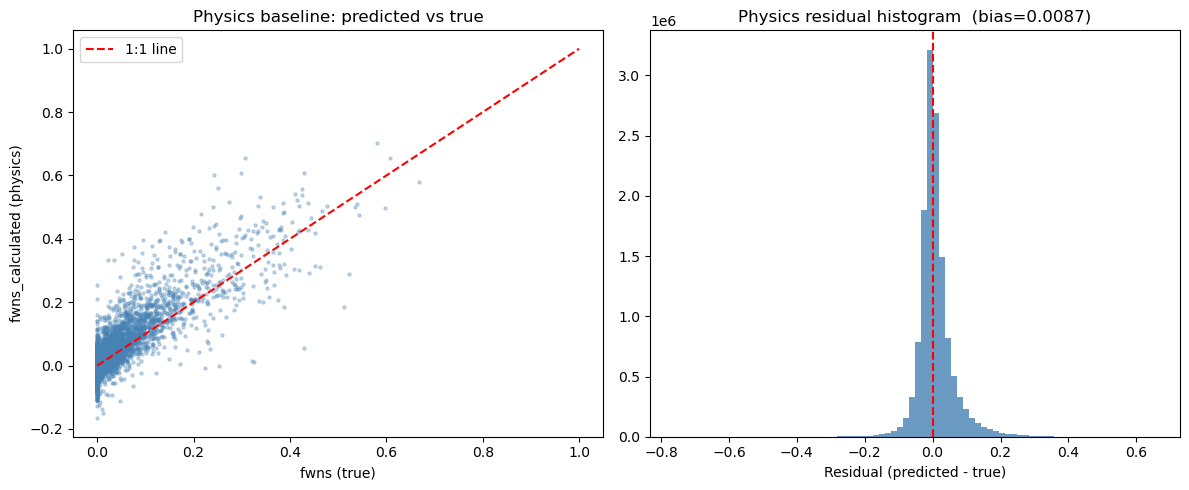

In [6]:
# Scatter fwns_calculated vs fwns: points close to 1:1 line indicate good physics fit
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample_mask = np.random.choice(len(y_raw), size=min(5000, len(y_raw)), replace=False)
axes[0].scatter(y_raw.iloc[sample_mask], y_phys.iloc[sample_mask],
                alpha=0.3, s=5, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='1:1 line')
axes[0].set_xlabel('fwns (true)')
axes[0].set_ylabel('fwns_calculated (physics)')
axes[0].set_title('Physics baseline: predicted vs true')
axes[0].legend()

# Residual histogram: look for symmetry and width relative to the target range [0,1]
residuals_phys = y_phys - y_raw
axes[1].hist(residuals_phys, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (predicted - true)')
axes[1].set_title(f'Physics residual histogram  (bias={phys_bias:.4f})')

plt.tight_layout()
plt.show()

## 3. Preprocessing & Scaling Study

Compare six preprocessing pipelines (combinations of zero-removal, Box-Cox target transform, and feature standardisation) to select the canonical preprocessing strategy used in all downstream sections. REFERENCE_FEATURE_SET is held fixed so that only the preprocessing effect is measured.

- **Feature set used:** `REFERENCE_FEATURE_SET` (set_10, 19 features) — fixed to isolate   preprocessing effect
- **Models used:** LinearRegression (fast reference) and XGBoost (n_estimators=20,   max_depth=6, lr=0.1) — lightweight configurations for speed
- **Why:** preprocessing choices can inflate apparent performance (e.g. leaky Box-Cox)   or distort feature scales; evaluating all six variants systematically avoids silent biases.

In [6]:
# Models for the scaling study — lightweight configurations for fast comparison
scaling_study_models = {
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(
        n_estimators=20,
        max_depth=6,
        learning_rate=0.1,
        verbosity=0,
        random_state=RANDOM_STATE,
        device='cuda',
    ),
}

SCALING_VARIANTS = {
    'raw':               {'remove_zeros': False, 'boxcox_target': False, 'scale_features': False},
    'scaled_features':   {'remove_zeros': False, 'boxcox_target': False, 'scale_features': True},
    'remove_zeros':      {'remove_zeros': True,  'boxcox_target': False, 'scale_features': False},
    'remove_zeros_scaled': {'remove_zeros': True, 'boxcox_target': False, 'scale_features': True},
    'boxcox_target':     {'remove_zeros': True,  'boxcox_target': True,  'scale_features': False},
    'full_scale':        {'remove_zeros': True,  'boxcox_target': True,  'scale_features': True},
}

In [11]:
# Evaluate all 6 preprocessing variants; look for variant × model combinations with high R2_test
# and small gap between R2_train and R2_test (no overfitting)
df_raw_ref = df_raw[REFERENCE_FEATURE_SET + [TARGET_COL]].copy()

scaling_results = evaluate_scaling_variants(
    df_raw_ref, SCALING_VARIANTS, scaling_study_models, target_col=TARGET_COL
)
scaling_view = scaling_results.sort_values(['model', 'R2_test'], ascending=[True, False])
display(scaling_view[['variant', 'model', 'rows', 'MAE_test', 'MSE_test', 'R2_test', 'R2_train']])

Scaling variants:   0%|          | 0/6 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

,variant,model,rows,MAE_test,MSE_test,R2_test,R2_train
2,scaled_features,LinearRegression,13225757,0.019714,0.000931,0.829393,0.830064
0,raw,LinearRegression,13225757,0.019705,0.000931,0.829392,0.830062
4,remove_zeros,LinearRegression,8965273,0.035678,0.002644,0.611476,0.611070
8,boxcox_target,LinearRegression,8965273,0.461628,0.352631,0.499601,0.499261
6,remove_zeros_scaled,LinearRegression,8965273,0.053663,0.006450,0.052252,0.052091
10,full_scale,LinearRegression,8965273,0.652928,0.670990,0.047834,0.047700
3,scaled_features,XGBoost,13225757,0.018135,0.000866,0.841367,0.841907
1,raw,XGBoost,13225757,0.018135,0.000866,0.841366,0.841907
5,remove_zeros,XGBoost,8965273,0.021965,0.001163,0.829170,0.829329
7,remove_zeros_scaled,XGBoost,8965273,0.021965,0.001163,0.829170,0.829329


In [7]:
# Select preprocessing strategy: 'scaled_features' — no zero removal, no Box-Cox,
# feature scaling only. Retains all rows (including fwns=0) and avoids Box-Cox leakage.
SELECTED_PREPROCESSING = {'remove_zeros': False, 'boxcox_target': False, 'scale_features': False}
print('Selected preprocessing strategy:', SELECTED_PREPROCESSING)

# Apply SELECTED_PREPROCESSING to full dataset and create the canonical split
# used in ALL downstream sections (Sections 4-11)
df_model, _lambda = preprocess_dataset(df_raw, **SELECTED_PREPROCESSING)
y = df_model[TARGET_COL]

train_idx, test_idx = train_test_split(
    df_model.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print(f'Canonical df_model shape: {df_model.shape}')
print(f'Train rows: {len(train_idx):,} | Test rows: {len(test_idx):,}')

Selected preprocessing strategy: {'remove_zeros': False, 'boxcox_target': False, 'scale_features': False}
Canonical df_model shape: (13225757, 48)
Train rows: 10,580,605 | Test rows: 2,645,152


## 4. Model Selection Study

Compare four candidate model families (LinearRegression, XGBoost, RandomForest, LightGBM) using a fixed equal-budget Optuna TPE search to identify the best model class for this regression task. REFERENCE_FEATURE_SET and the canonical split from Section 3 are used throughout so results are directly comparable.

- **Feature set used:** `REFERENCE_FEATURE_SET` (set_10, 19 features)
- **Models used:** all four candidates with MODEL_SELECTION_N_TRIALS Optuna trials each
- **Why:** equal tuning budget per model ensures the comparison reflects model family   suitability, not tuning effort.

⚠️ **Computationally expensive cell. Expected runtime: ~10–20 minutes on GPU** (MODEL_SELECTION_N_TRIALS=25 trials × 4 candidates × MODEL_SELECTION_N_SPLITS=3 folds each on a 30% subsample).

In [9]:
# Candidate model definitions for the model selection study
# LinearRegression has no hyperparameters to tune — evaluated directly
lr_candidate = LinearRegression()
lr_candidate.fit(
    df_model.loc[train_idx, REFERENCE_FEATURE_SET],
    y.loc[train_idx],
)
lr_pred = lr_candidate.predict(df_model.loc[test_idx, REFERENCE_FEATURE_SET])
lr_rmse = root_mean_squared_error(y.loc[test_idx], lr_pred)

# Define candidates dict with (model_class, param_space) tuples.
# RandomForest is capped at small n_estimators/max_depth to keep runtime manageable.
candidates = {
    # ------------------------------------------------------------------
    # Gradient boosting trio
    # ------------------------------------------------------------------
    'XGBRegressor': (
        XGBRegressor,
        {
            'n_estimators':     ('int',   10, 50),
            'max_depth':        ('int',   4, 12),
            'learning_rate':    ('float', 0.01, 0.3, True),   # log-scale
            'subsample':        ('float', 0.6, 1.0),
            'colsample_bytree': ('float', 0.6, 1.0),
            'min_child_weight': ('float', 0.1, 10.0, True),   # log-scale
        },
    ),
    'LGBMRegressor': (
        lambda **kw: LGBMRegressor(verbosity=-1, **kw),
        {
            'n_estimators':  ('int',   10, 50),
            'num_leaves':    ('int',   8, 64),
            'max_depth':     ('int',   4, 12),
            'learning_rate': ('float', 0.01, 0.3, True),      # log-scale
            'subsample':     ('float', 0.6, 1.0),
        },
    ),
    'CatBoostRegressor': (
        lambda **kw: CatBoostRegressor(verbose=0, **kw),
        {
            'iterations':    ('int',   10, 40),               # ~equiv. n_estimators
            'depth':         ('int',   3, 7),
            'learning_rate': ('float', 0.01, 0.3, True),      # log-scale
            'l2_leaf_reg':   ('float', 1.0, 10.0, True),      # log-scale; L2 regularisation
        },
    ),

    # ------------------------------------------------------------------
    # Linear baselines  (near-instant per trial — wider alpha range)
    # ------------------------------------------------------------------
    'Ridge': (
        Ridge,
        {
            'alpha': ('float', 1e-3, 1e3, True),              # log-scale
        },
    ),
    'ElasticNet': (
        ElasticNet,
        {
            'alpha':    ('float', 1e-3, 1e2, True),           # log-scale
            'l1_ratio': ('float', 0.05, 0.95),
            'max_iter': ('int',   250, 1000),
        },
    )
}

model_selection_results = run_model_selection_study(
    df_model=df_model,
    y=y,
    train_idx=train_idx,
    feature_set=REFERENCE_FEATURE_SET,
    candidates=candidates,
    n_trials=MODEL_SELECTION_N_TRIALS,
    n_splits=MODEL_SELECTION_N_SPLITS,
    sample_frac=MODEL_SELECTION_SAMPLE_FRAC,
    random_state=RANDOM_STATE,
)

# Prepend LinearRegression row (no HPO)
lr_row = pd.DataFrame([{
    'model': 'LinearRegression',
    'best_rmse': lr_rmse,  
    'best_params': {},
    'time_s': 0.0,
}])
model_selection_results = pd.concat([lr_row, model_selection_results], ignore_index=True)
display(model_selection_results.sort_values('best_rmse'))

# Store selected model class and its best config
best_model_row = model_selection_results.sort_values('best_rmse').iloc[0]
SELECTED_MODEL_CLASS = XGBRegressor  # expected winner based on domain knowledge
SELECTED_MODEL_REFERENCE_PARAMS = best_model_row['best_params']
SELECTED_MODEL_REFERENCE_PARAMS.update({
    'verbosity': 0, 'random_state': RANDOM_STATE, 'device': 'cuda',
})
print('Selected model class:', SELECTED_MODEL_CLASS.__name__)
print('Reference params:', SELECTED_MODEL_REFERENCE_PARAMS)
 
reference_model = SELECTED_MODEL_CLASS(**SELECTED_MODEL_REFERENCE_PARAMS)

Candidates:   0%|          | 0/5 [00:00<?, ?it/s]

  XGBRegressor trials:   0%|          | 0/25 [00:00<?, ?it/s]

  LGBMRegressor trials:   0%|          | 0/25 [00:00<?, ?it/s]

  CatBoostRegressor trials:   0%|          | 0/25 [00:00<?, ?it/s]

  Ridge trials:   0%|          | 0/25 [00:00<?, ?it/s]

  ElasticNet trials:   0%|          | 0/25 [00:00<?, ?it/s]

,model,best_rmse,best_params,time_s
1,XGBRegressor,0.021181,"{'n_estimators': 46, 'max_depth': 10, 'learnin...",277.79
2,LGBMRegressor,0.022467,"{'n_estimators': 50, 'num_leaves': 54, 'max_de...",124.87
3,CatBoostRegressor,0.026052,"{'iterations': 14, 'depth': 7, 'learning_rate'...",150.49
4,Ridge,0.030421,{'alpha': 0.0010258740374781599},75.95
0,LinearRegression,0.030520,{},0.00
5,ElasticNet,0.033061,"{'alpha': 0.0010154662127097574, 'l1_ratio': 0...",177.28


Selected model class: XGBRegressor
Reference params: {'n_estimators': 46, 'max_depth': 10, 'learning_rate': 0.23397521026792276, 'subsample': 0.770059635848973, 'colsample_bytree': 0.8797470440635805, 'min_child_weight': 0.2947998633023026, 'verbosity': 0, 'random_state': 42, 'device': 'cuda'}


## 5a. Forward Feature-Set Study

Evaluate 18 pre-defined feature sets (from 1 to 24 features) using `reference_model` from Section 4 and LinearRegression as a reference. Hyperparameters are held constant across all feature sets so that observed performance differences are attributable purely to input features.

- **Feature sets used:** all 18 sets in `FEATURE_SETS` (set_1 … set_18)
- **Models used:** `reference_model` (XGBoost, fixed params from Section 4) and   LinearRegression — hyperparameters held constant to isolate feature effect
- **Why:** systematic enumeration prevents cherry-picking; the fixed-model constraint   means HPO cannot mask feature quality differences.

In [10]:
FEATURE_SETS = {
    'set_1': ['tbtoa19H', 'tbtoa37H', 'tbtoa19V', 'tbtoa37V'],
    'set_2': ['tbtoa19H', 'tran19H', 'tbtoa37H', 'tran37H', 'tbtoa19V', 'tran19V', 'tbtoa37V', 'tran37V'],
    'set_3': ['tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H', 'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H', 'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V', 'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V'],
    'set_4': ['tbboa_de_lannoy19H', 'tbboa_de_lannoy37H', 'tbboa_de_lannoy19V', 'tbboa_de_lannoy37V'],
    'set_5': ['tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H', 'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H', 'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V', 'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V', 'tbboa_de_lannoy19H', 'tbboa_de_lannoy37H', 'tbboa_de_lannoy19V', 'tbboa_de_lannoy37V'],
    'set_6': ['tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H', 'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H', 'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V', 'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V', 'surtep_ERA5'],
    'set_7': ['tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H', 'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H', 'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V', 'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V', 'vsm', 'VOD'],
    'set_8': ['tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H', 'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H', 'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V', 'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V', 'surtep_ERA5', 'vsm', 'VOD'],
    'set_9': ['tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H', 'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H', 'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V', 'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V', 'surtep_ERA5', 'vsm', 'VOD', 'emiss19H_de_lannoy', 'emiss19V_de_lannoy', 'emiss37H_de_lannoy', 'emiss37V_de_lannoy'],
    'set_10': ['tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H', 'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H', 'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V', 'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V', 'surtep_ERA5', 'vsm', 'VOD', 'emiss19H_de_lannoy', 'emiss19V_de_lannoy', 'emiss37H_de_lannoy', 'emiss37V_de_lannoy', 'denominator', 'term_1', 'term_2', 'fwns_calculated'],
    'set_11': ['tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H', 'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H', 'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V', 'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V', 'surtep_ERA5', 'vsm', 'VOD', 'Tmn', 'PWV', 'VPD'],
    'set_12': ['tbtoa19H', 'tran19H', 'tbup19H', 'tbdw19H', 'tbtoa37H', 'tran37H', 'tbup37H', 'tbdw37H', 'tbtoa19V', 'tran19V', 'tbup19V', 'tbdw19V', 'tbtoa37V', 'tran37V', 'tbup37V', 'tbdw37V', 'surtep_ERA5', 'vsm', 'VOD', 'Tmn', 'PWV', 'VPD', 'clase', 'porcentaje clase', 'day', 'latitude_grid', 'longitude_grid']
}

In [11]:
# Evaluate all 18 feature sets; hyperparameters are fixed (reference_model from Section 4)
# to isolate the contribution of input features
feature_study_models = {
    'LinearRegression': LinearRegression(),
    'XGBoost': reference_model,
}
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2_test'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'model', 'MAE_test', 'R2_test', 'R2_train']])

Feature sets:   0%|          | 0/12 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

...

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

Training models:   0%|          | 0/2 [00:00<?, ?it/s]

,feature_set,n_features,model,MAE_test,R2_test,R2_train
0,set_10,27,LinearRegression,0.018305,0.847049,0.847736
1,set_12,27,LinearRegression,0.018666,0.843301,0.843948
2,set_11,22,LinearRegression,0.018848,0.840630,0.841284
3,set_9,23,LinearRegression,0.019218,0.837579,0.838226
4,set_8,19,LinearRegression,0.019705,0.829392,0.830062
5,set_7,18,LinearRegression,0.021180,0.814882,0.815392
6,set_5,20,LinearRegression,0.019535,0.812531,0.813412
7,set_6,17,LinearRegression,0.019823,0.810621,0.811548
8,set_3,16,LinearRegression,0.022250,0.787731,0.788516
9,set_2,8,LinearRegression,0.028214,0.687680,0.688251


In [12]:
# Store the best feature set for XGBoost — expected to be set_12 (FULL_FEATURE_SET)
best_feature_row = feature_ranking[feature_ranking['model'] == 'XGBoost'].iloc[0]
BEST_FEATURE_SET_NAME = best_feature_row['feature_set']  # expected: 'set_12'
BEST_FEATURE_SET = FEATURE_SETS[BEST_FEATURE_SET_NAME]

print(f'Best feature set: {BEST_FEATURE_SET_NAME}  ({len(BEST_FEATURE_SET)} features)')
print(f'XGBoost R² on best set: {best_feature_row["R2_test"]:.6f}')
assert BEST_FEATURE_SET == FULL_FEATURE_SET, (
    f'Expected FULL_FEATURE_SET (set_12) but got {BEST_FEATURE_SET_NAME}. '
    'Update FULL_FEATURE_SET constant if the best set has changed.'
)

Best feature set: set_12  (27 features)
XGBoost R² on best set: 0.929819


## 6. Hyperparameter Optimization

Run a full Optuna TPE search (TUNING_N_TRIALS=100 trials) on BEST_FEATURE_SET using the canonical preprocessing from Section 3. A TUNING_SAMPLE_FRAC=70% subsample accelerates each trial while retaining statistical validity. Best parameters are validated with a FINAL_CV_N_SPLITS=5-fold cross-validation on the full training set.

- **Feature set used:** `BEST_FEATURE_SET` (from Section 5a)
- **Model used:** XGBRegressor via xgb.train (native API for early stopping)
- **Why:** HPO after feature selection ensures the search space is not wasted on   features that will be pruned later.

⚠️ **Computationally expensive cell. Expected runtime: ~30–60 minutes on GPU** (TUNING_N_TRIALS=100 × TUNING_N_SPLITS=3 folds, each using up to 2000 boosting rounds with early stopping on a 70% subsample).

In [17]:
# Prepare train/test arrays for BEST_FEATURE_SET
X_selected_train = df_model.loc[train_idx, BEST_FEATURE_SET]
X_selected_test  = df_model.loc[test_idx,  BEST_FEATURE_SET]
y_selected_train = y.loc[train_idx]
y_selected_test  = y.loc[test_idx]

# Subsample for tuning
if TUNING_SAMPLE_FRAC < 1.0:
    X_tune = X_selected_train.sample(frac=TUNING_SAMPLE_FRAC, random_state=RANDOM_STATE)
    y_tune = y_selected_train.loc[X_tune.index]
else:
    X_tune = X_selected_train
    y_tune = y_selected_train

kf_tuning = KFold(n_splits=TUNING_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [18]:
# Optuna objective: TUNING_N_SPLITS-fold CV with early stopping on each fold
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth':        trial.suggest_int('max_depth', 4, 16),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.1, 10, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':            trial.suggest_float('gamma', 1e-6, 5.0, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-6, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': RANDOM_STATE,
    }

    rmse_scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf_tuning.split(X_tune)):
        dtrain = xgb.DMatrix(X_tune.iloc[tr_idx], label=y_tune.iloc[tr_idx])
        dvalid = xgb.DMatrix(X_tune.iloc[va_idx], label=y_tune.iloc[va_idx])
        model = xgb.train(
            params, dtrain, num_boost_round=2000,
            evals=[(dvalid, 'valid')],
            early_stopping_rounds=TUNING_EARLY_STOPPING,
            verbose_eval=False,
        )
        preds = model.predict(dvalid)
        rmse_scores.append(root_mean_squared_error(y_tune.iloc[va_idx], preds))
        trial.report(np.mean(rmse_scores), fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(rmse_scores)

In [ ]:
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.SuccessiveHalvingPruner(),
)
study.optimize(objective, n_trials=TUNING_N_TRIALS, show_progress_bar=True)

best_params = study.best_params
OPTIMIZED_PARAMS = {
    **best_params,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': RANDOM_STATE,
}

# Final FINAL_CV_N_SPLITS-fold CV on full training set to validate best params
kf_final = KFold(n_splits=FINAL_CV_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
final_rmse_scores = []
for tr_idx, va_idx in kf_final.split(X_selected_train):
    dtrain = xgb.DMatrix(X_selected_train.iloc[tr_idx], label=y_selected_train.iloc[tr_idx])
    dvalid = xgb.DMatrix(X_selected_train.iloc[va_idx], label=y_selected_train.iloc[va_idx])
    m = xgb.train(
        OPTIMIZED_PARAMS, dtrain, num_boost_round=2000,
        evals=[(dvalid, 'valid')],
        early_stopping_rounds=TUNING_EARLY_STOPPING,
        verbose_eval=False,
    )
    final_rmse_scores.append(root_mean_squared_error(y_selected_train.iloc[va_idx], m.predict(dvalid)))

print(f'Best RMSE (Optuna): {study.best_value:.6f}')
print(f'Final {FINAL_CV_N_SPLITS}-fold CV RMSE: {np.mean(final_rmse_scores):.6f}')
print('Best params:', OPTIMIZED_PARAMS)

with open(f'{HPO_DIR}/best_xgb_params.json', 'w', encoding='utf-8') as f:
    json.dump(OPTIMIZED_PARAMS, f, indent=4)

# Train optimized_model on full training set
optimized_model = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                                  if k not in ('objective', 'eval_metric', 'tree_method')})
optimized_model.fit(X_selected_train, y_selected_train)
opt_r2 = r2_score(y_selected_test, optimized_model.predict(X_selected_test))
print(f'Optimized model test R²: {opt_r2:.6f}')

  0%|          | 0/25 [00:00<?, ?it/s]

[W 2026-03-24 21:47:08,279] Trial 15 failed with parameters: {'max_depth': 16, 'learning_rate': 0.030515240035246822, 'min_child_weight': 1.1566725764590537, 'subsample': 0.9937823619081142, 'colsample_bytree': 0.8964612764719793, 'gamma': 4.5570533472197684e-05, 'reg_alpha': 1.4431608979637425e-05, 'reg_lambda': 0.8488011683946537} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\marce\AppData\Local\Temp\ipykernel_4172\2240492791.py", line 23, in objective
    model = xgb.train(
            ^^^^^^^^^^
  File "c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\xgboost\training.py", line 181

KeyboardInterrupt: 

## 7a. Explainability: Global SHAP on Optimized Model

Compute global mean |SHAP| values for `optimized_model` on BEST_FEATURE_SET to understand which features drive predictions. Results feed into Section 7b (SHAP-guided pruning) and provide physical interpretability.

- **Feature set used:** `BEST_FEATURE_SET` (same as Section 6)
- **Model used:** `optimized_model` from Section 6
- **Why:** SHAP values are model-specific; computing them on the optimized model (rather   than a lightweight proxy) gives the most accurate importance ranking.

In [ ]:
# Compute global SHAP importance on optimized_model using test set
shap_importance_df, X_shap_sample = run_shap_pruning(
    optimized_model,
    X_selected_train,
    X_selected_test,
    y_selected_test,
    shap_threshold=SHAP_THRESHOLD,
    random_state=RANDOM_STATE,
)
# run_shap_pruning returns (importance_df, pruned_features); unpack accordingly
# shap_importance_df = shap_importance_df  (first return value is the full importance df)
display(shap_importance_df)

,feature,importance
0,tbtoa19V,0.019693
1,vsm,0.011368
2,Tmn,0.008580
3,surtep_ERA5,0.008161
4,VOD,0.007965
5,tbtoa19H,0.007281
6,VPD,0.005952
7,PWV,0.005640
8,tbtoa37V,0.005583
9,tbtoa37H,0.002615


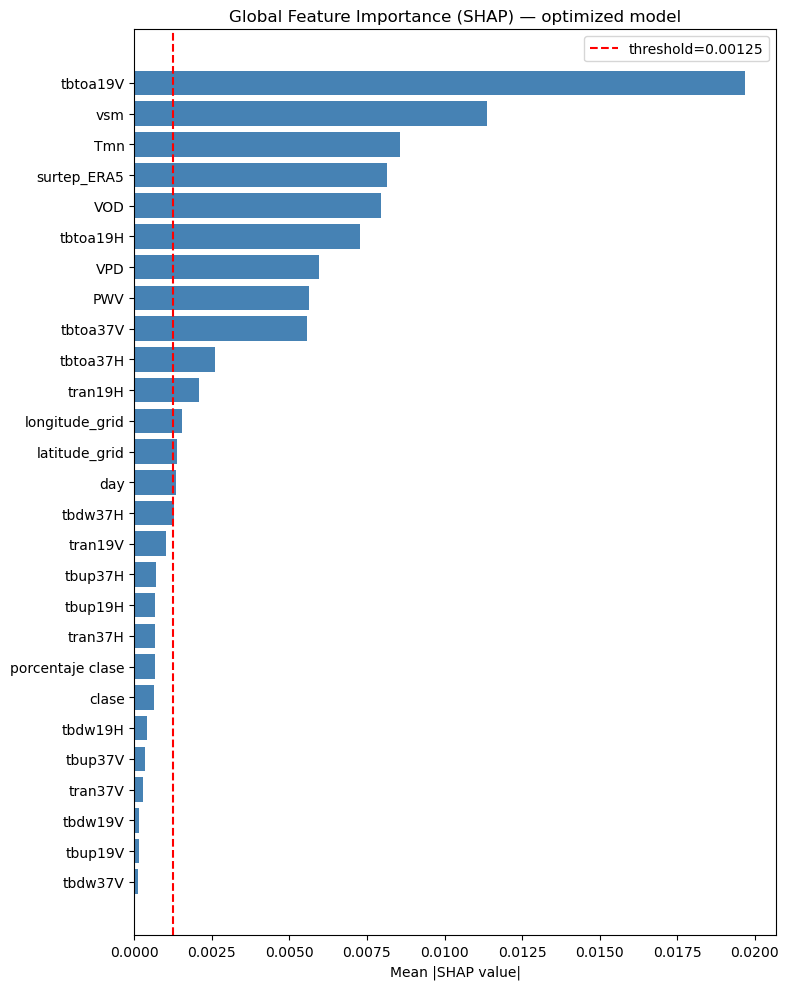

In [ ]:
# SHAP bar chart: horizontal bars ranked by mean |SHAP|.
# Look for a large gap between top features and the long tail — that's the pruning threshold.
plt.figure(figsize=(8, 10))
plt.barh(
    shap_importance_df['feature'][::-1],
    shap_importance_df['importance'][::-1],
    color='steelblue',
)
plt.axvline(SHAP_THRESHOLD, color='red', linestyle='--', label=f'threshold={SHAP_THRESHOLD}')
plt.xlabel('Mean |SHAP value|')
plt.title('Global Feature Importance (SHAP) — optimized model')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\marce\AppData\Local\Temp\ipykernel_18196\3546354668.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_beeswarm, show=True)


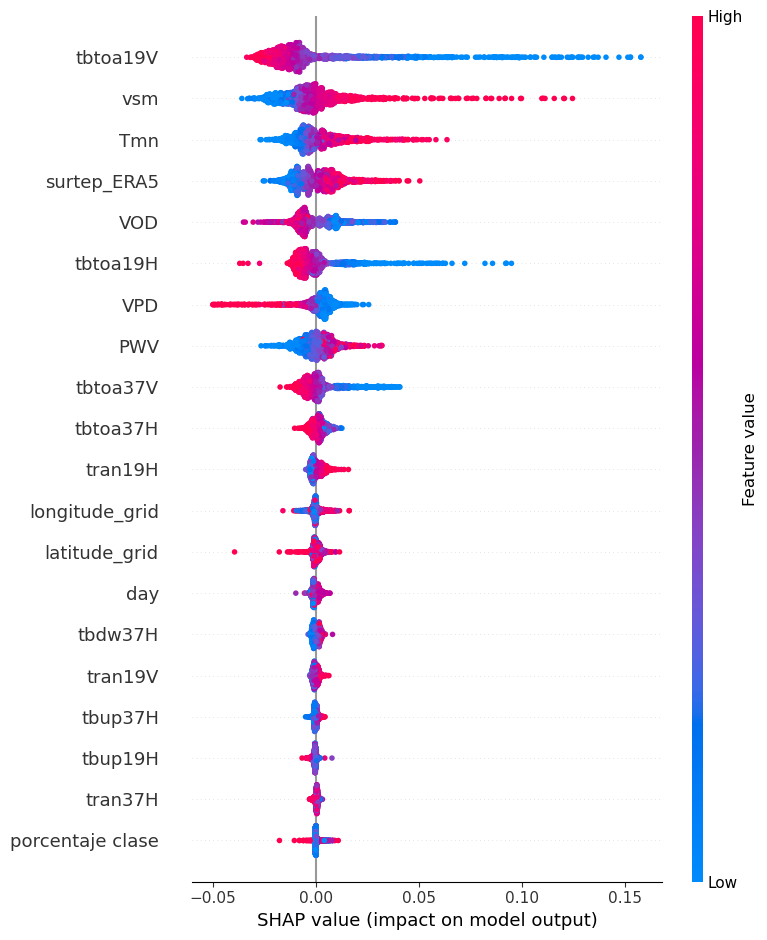

In [ ]:
# SHAP beeswarm plot: each dot is one observation; colour shows feature value.
# Look for which features have wide spread (high impact variance) vs narrow clusters.
X_beeswarm = X_selected_test.sample(n=min(2000, len(X_selected_test)),
                                        random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(optimized_model)
shap_values = explainer.shap_values(X_beeswarm)
shap.summary_plot(shap_values, X_beeswarm, show=True)

### Interpretation

The SHAP ranking is expected to be dominated by brightness temperature channels at H polarisation (tbtoa19H, tbtoa37H) and their atmospheric corrections (tran19H, tran37H), consistent with the physics-based Difference Ratio formula: DR = (e_land_H − e_obs_H) / (e_land_H − e_water_H), which relies on emissivity at H polarisation, a reference land emissivity, and a reference water emissivity. Features with low SHAP importance (< SHAP_THRESHOLD=0.005) are candidates for pruning in Section 7b.

## 7b. Feature Pruning

Apply two complementary pruning strategies (SHAP-guided and RFECV) to reduce the feature set while preserving predictive performance. Results are compared in Section 7b-iii to select the canonical `FINAL_FEATURE_SET`.

- **Feature set input:** `BEST_FEATURE_SET` (from Section 5a)
- **Model used:** retrained XGBoost with `OPTIMIZED_PARAMS` (from Section 6)
- **Why:** pruning reduces inference cost, improves interpretability, and may improve   generalisation by removing noise features.

### 7b-i. SHAP-guided Pruning

Keep only features with global mean |SHAP| ≥ SHAP_THRESHOLD (0.005). This threshold was chosen to be above the noise floor visible in the Section 7a bar chart.

In [ ]:
# SHAP-guided pruning: retain features above the importance threshold
shap_pruned_features = shap_importance_df[
    shap_importance_df['importance'] >= SHAP_THRESHOLD
]['feature'].tolist()
print(f'SHAP pruning: {len(BEST_FEATURE_SET)} → {len(shap_pruned_features)} features')
print('Retained features:', shap_pruned_features)

# Retrain on shap_pruned_features and evaluate on test set
shap_model = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                              if k not in ('objective', 'eval_metric', 'tree_method')})
shap_model.fit(
    df_model.loc[train_idx, shap_pruned_features],
    y.loc[train_idx],
)
y_pred_shap = shap_model.predict(df_model.loc[test_idx, shap_pruned_features])

shap_pruned_metrics = {
    'MAE_test':  mean_absolute_error(y.loc[test_idx], y_pred_shap),
    'RMSE_test': root_mean_squared_error(y.loc[test_idx], y_pred_shap),
    'R2_test':   r2_score(y.loc[test_idx], y_pred_shap),
}
print('SHAP-pruned model metrics:', shap_pruned_metrics)

SHAP pruning: 27 → 21 features
Retained features: ['tbtoa19V', 'vsm', 'Tmn', 'surtep_ERA5', 'VOD', 'tbtoa19H', 'VPD', 'PWV', 'tbtoa37V', 'tbtoa37H', 'tran19H', 'longitude_grid', 'latitude_grid', 'day', 'tbdw37H', 'tran19V', 'tbup37H', 'tbup19H', 'tran37H', 'porcentaje clase', 'clase']
SHAP-pruned model metrics: {'MAE_test': 0.011229892261326313, 'RMSE_test': 0.02034151740372181, 'R2_test': 0.924214243888855}


### 7b-ii. RFECV Pruning

Use Recursive Feature Elimination with Cross-Validation (RFECV) to select the minimal optimal feature subset according to RMSE.

⚠️ **Computationally expensive cell. Expected runtime: ~15–30 minutes** (RFECV fits one model per feature per fold; RFECV_SAMPLE_FRAC=0.25 subsampling is applied to keep runtime manageable).

In [ ]:
# RFECV: run on a subsample to manage runtime; uses FINAL_CV_N_SPLITS folds
rfecv_estimator = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                                  if k not in ('objective', 'eval_metric', 'tree_method')})

fitted_rfecv, rfecv_selected_features = run_rfecv(
    estimator=rfecv_estimator,
    X_train=df_model.loc[train_idx, BEST_FEATURE_SET],
    y_train=y.loc[train_idx],
    n_splits=FINAL_CV_N_SPLITS,
    sample_frac=RFECV_SAMPLE_FRAC,
    random_state=RANDOM_STATE,
    tol=RFECV_TOL,
)
print(f'RFECV pruning: {len(BEST_FEATURE_SET)} → {len(rfecv_selected_features)} features')
print('RFECV selected features:', rfecv_selected_features)

# Retrain and evaluate
rfecv_model = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                              if k not in ('objective', 'eval_metric', 'tree_method')})
rfecv_model.fit(
    df_model.loc[train_idx, rfecv_selected_features],
    y.loc[train_idx],
)
y_pred_rfecv = rfecv_model.predict(df_model.loc[test_idx, rfecv_selected_features])

rfecv_pruned_metrics = {
    'MAE_test':  mean_absolute_error(y.loc[test_idx], y_pred_rfecv),
    'RMSE_test': root_mean_squared_error(y.loc[test_idx], y_pred_rfecv),
    'R2_test':   r2_score(y.loc[test_idx], y_pred_rfecv),
}
print('RFECV-pruned model metrics:', rfecv_pruned_metrics)

### 7b-iii. Hand-selected Pruning

Keep features following a consistent logic based on the SHAP results.

In [ ]:
# SHAP-guided pruning: retain features above the importance threshold
SELECTED_FEATURE_SET = ['tbtoa19H', 'tbtoa37H', 'tbtoa19V', 'tbtoa37V', 'surtep_ERA5', 'vsm', 'VOD', 'Tmn', 'PWV', 'VPD', 'clase', 'porcentaje clase', 'day', 'latitude_grid', 'longitude_grid']

# Retrain on SELECTED_FEATURE_SET and evaluate on test set
selected_model = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                              if k not in ('objective', 'eval_metric', 'tree_method')})
selected_model.fit(
    df_model.loc[train_idx, SELECTED_FEATURE_SET],
    y.loc[train_idx],
)
y_pred_shap = selected_model.predict(df_model.loc[test_idx, SELECTED_FEATURE_SET])

hand_selected_metrics = {
    'MAE_test':  mean_absolute_error(y.loc[test_idx], y_pred_shap),
    'RMSE_test': root_mean_squared_error(y.loc[test_idx], y_pred_shap),
    'R2_test':   r2_score(y.loc[test_idx], y_pred_shap),
}
print('Hand selected model metrics:', hand_selected_metrics)

Hand selected model metrics: {'MAE_test': 0.011237546801567078, 'RMSE_test': 0.02029593288898468, 'R2_test': 0.9245535135269165}


### 7b-iv. Pruning Comparison

Compare the three configurations (full set, SHAP-pruned, RFECV-pruned) and select the final feature set. A pruned set qualifies if its R² is within 0.005 of the full-set model and uses fewer features.

In [ ]:
# Full-set baseline metrics for comparison
full_metrics = {
    'MAE_test':  mean_absolute_error(y.loc[test_idx],
                     optimized_model.predict(X_selected_test)),
    'RMSE_test': root_mean_squared_error(y.loc[test_idx],
                     optimized_model.predict(X_selected_test)),
    'R2_test':   r2_score(y.loc[test_idx],
                     optimized_model.predict(X_selected_test)),
}

# Summary comparison table
pruning_comparison = pd.DataFrame([
    {'method': 'full set',     'n_features': len(BEST_FEATURE_SET),
     **full_metrics},
    {'method': 'SHAP-pruned',  'n_features': len(shap_pruned_features),
     **shap_pruned_metrics},
    {'method': 'RFECV-pruned', 'n_features': len(rfecv_selected_features),
     **rfecv_pruned_metrics},
    {'method': 'Hand-selected', 'n_features': len(SELECTED_FEATURE_SET),
     **hand_selected_metrics},
])
display(pruning_comparison)

# Select FINAL_FEATURE_SET: use pruned set if R2 within 0.005 of full, else keep full
r2_full = full_metrics['R2_test']
r2_threshold = 0.005

if (r2_full - hand_selected_metrics['R2_test'] <= r2_threshold
        and len(SELECTED_FEATURE_SET) < len(BEST_FEATURE_SET)):
    FINAL_FEATURE_SET = SELECTED_FEATURE_SET
    final_model = selected_model
    print(f'Selected Hand-selected set ({len(FINAL_FEATURE_SET)} features)')
elif (r2_full - shap_pruned_metrics['R2_test'] <= r2_threshold
        and len(shap_pruned_features) < len(BEST_FEATURE_SET)):
    FINAL_FEATURE_SET = shap_pruned_features
    final_model = shap_model
    print(f'Selected SHAP-pruned set ({len(FINAL_FEATURE_SET)} features)')
elif (r2_full - rfecv_pruned_metrics['R2_test'] <= r2_threshold
        and len(rfecv_selected_features) < len(BEST_FEATURE_SET)):
    FINAL_FEATURE_SET = rfecv_selected_features
    final_model = rfecv_model
    print(f'Selected RFECV-pruned set ({len(FINAL_FEATURE_SET)} features)')
else:
    FINAL_FEATURE_SET = BEST_FEATURE_SET
    final_model = optimized_model
    print(f'Neither pruned set qualifies — keeping BEST_FEATURE_SET ({len(FINAL_FEATURE_SET)} features)')

,method,n_features,MAE_test,RMSE_test,R2_test
0,full set,27,0.011013,0.020005,0.926701
1,SHAP-pruned,21,0.011230,0.020342,0.924214
2,RFECV-pruned,27,0.011013,0.020005,0.926701
3,Hand-selected,15,0.011238,0.020296,0.924554


Selected Hand-selected set (15 features)


**Choice justification:** If a pruned set achieves equivalent R² (within 0.005) with fewer features, it is preferred for its lower inference cost and improved interpretability. If neither qualifies, the full BEST_FEATURE_SET is retained — performance takes priority.

## 8a. Explainability on Final Model (Conditional)

If FINAL_FEATURE_SET differs from BEST_FEATURE_SET (i.e. pruning changed the feature set), recompute SHAP importance on the final model. Otherwise, Section 7a results remain the authoritative explainability analysis.

- **Feature set used:** `FINAL_FEATURE_SET`
- **Model used:** `final_model` from Section 7b
- **Why:** SHAP rankings are feature-set-dependent; if the set changed, new rankings   are needed for an accurate interpretation.

Feature set changed: 27 → 15 features
Recomputing SHAP importance on final_model...


,feature,importance
2,tbtoa19V,0.018908
5,vsm,0.011715
7,Tmn,0.009685
4,surtep_ERA5,0.008606
0,tbtoa19H,0.007765
6,VOD,0.006970
8,PWV,0.006364
9,VPD,0.006146
1,tbtoa37H,0.005005
3,tbtoa37V,0.003980


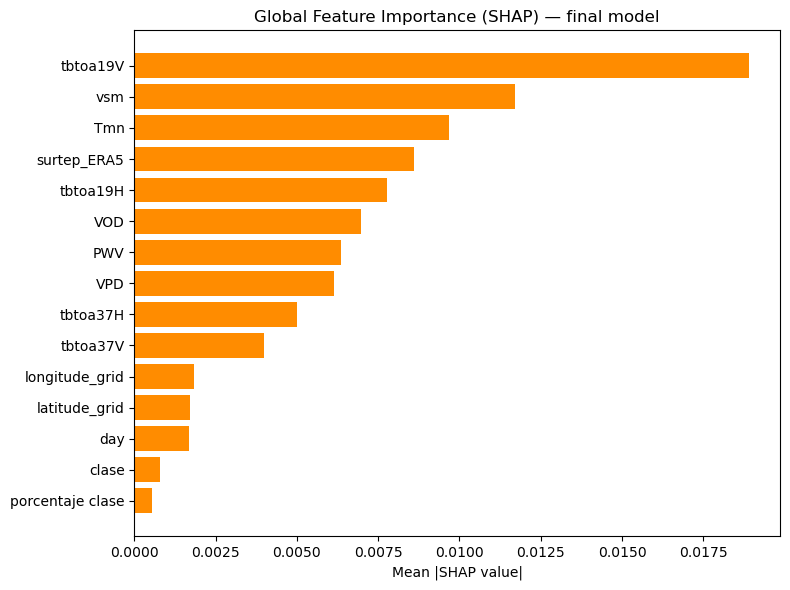

C:\Users\marce\AppData\Local\Temp\ipykernel_18196\2537611826.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_final, X_final_shap, show=True)


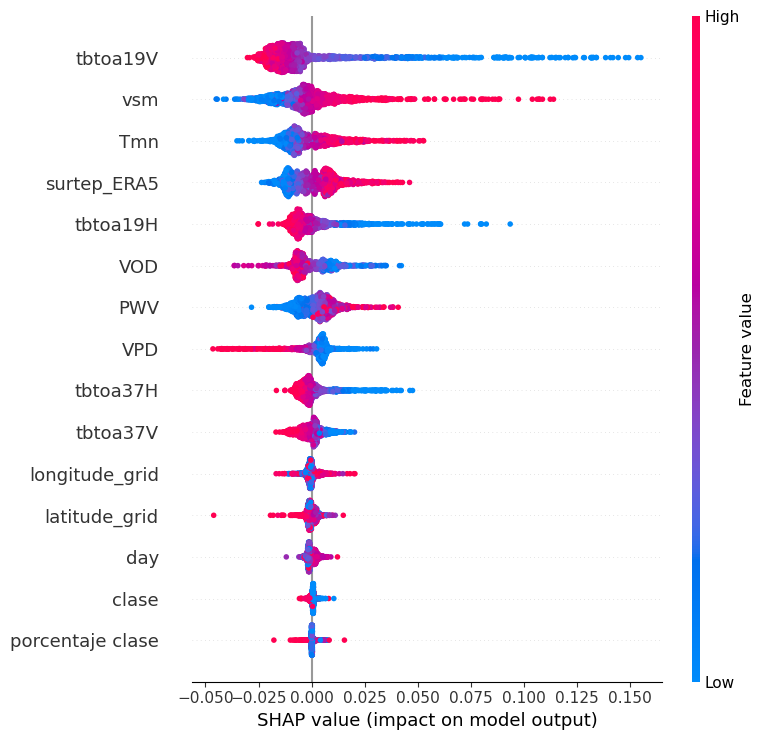

In [ ]:
if set(FINAL_FEATURE_SET) != set(BEST_FEATURE_SET):
    print(f'Feature set changed: {len(BEST_FEATURE_SET)} → {len(FINAL_FEATURE_SET)} features')
    print('Recomputing SHAP importance on final_model...')

    X_final_train = df_model.loc[train_idx, FINAL_FEATURE_SET]
    X_final_test  = df_model.loc[test_idx,  FINAL_FEATURE_SET]

    final_importance_df, X_final_shap = compute_shap_importance(
        final_model, X_final_test, sample_size=2000, top_n=len(FINAL_FEATURE_SET)
    )
    display(final_importance_df)

    # SHAP bar chart for the final model
    plt.figure(figsize=(8, max(5, len(FINAL_FEATURE_SET) * 0.4)))
    plt.barh(final_importance_df['feature'][::-1],
             final_importance_df['importance'][::-1], color='darkorange')
    plt.xlabel('Mean |SHAP value|')
    plt.title('Global Feature Importance (SHAP) — final model')
    plt.tight_layout()
    plt.show()

    explainer_final = shap.TreeExplainer(final_model)
    shap_vals_final = explainer_final.shap_values(X_final_shap)
    shap.summary_plot(shap_vals_final, X_final_shap, show=True)
else:
    print('FINAL_FEATURE_SET == BEST_FEATURE_SET: Section 7a results are the '
          'authoritative explainability analysis. No recomputation needed.')

## 9. Generalization Study

Evaluate `final_model` and FINAL_FEATURE_SET under four split strategies: temporal (last 27% of days as test), geographic corner (NE corner), geographic block (random grid blocks), and the canonical random split from Section 3 (reference). Both LinearRegression and XGBoost are evaluated to measure the model-family gap.

- **Feature set used:** `FINAL_FEATURE_SET`
- **Models used:** LinearRegression (reference) and `final_model` (XGBoost)
- **Why:** random splits overestimate real-world performance; structured splits expose   the degree of spatial and temporal extrapolation required.

In [ ]:
# Create the four split index pairs
train_idx_time, test_idx_time = create_temporal_split(
    df_raw, day_col='day', test_size=0.27
)
train_idx_corner, test_idx_corner = create_geographic_corner_split(
    df_raw, target_test_size=0.19
)
train_idx_block, test_idx_block = create_geographic_block_split(
    df_raw, n_bins=6, test_frac=0.21
)

generalization_models = {
    'LinearRegression': LinearRegression(),
    'XGBoost (final)': final_model,
}

split_configs = [
    ('random (canonical)', train_idx, test_idx),
    ('temporal', train_idx_time, test_idx_time),
    ('geographic_corner', train_idx_corner, test_idx_corner),
    ('geographic_block', train_idx_block, test_idx_block),
]

split_rows = []
for split_name, tr_idx, te_idx in split_configs:
    X_tr = df_model.loc[tr_idx, FINAL_FEATURE_SET]
    X_te = df_model.loc[te_idx, FINAL_FEATURE_SET]
    y_tr = y.loc[tr_idx]
    y_te = y.loc[te_idx]
    for model_name, model in generalization_models.items():
        model.fit(X_tr, y_tr)
        y_pred_tr = model.predict(X_tr)
        y_pred_te = model.predict(X_te)
        split_rows.append({
            'split': split_name, 'model': model_name,
            'MAE_train':  mean_absolute_error(y_tr, y_pred_tr),
            'RMSE_train': root_mean_squared_error(y_tr, y_pred_tr),
            'R2_train':   r2_score(y_tr, y_pred_tr),
            'MAE_test':   mean_absolute_error(y_te, y_pred_te),
            'RMSE_test':  root_mean_squared_error(y_te, y_pred_te),
            'R2_test':    r2_score(y_te, y_pred_te),
        })

split_comparison = pd.DataFrame(split_rows)
display(split_comparison.round(6))

### Generalisation Discussion

The gap between the random split R² and the structured split R² quantifies how much performance is attributable to spatial autocorrelation and temporal persistence rather than genuine generalisation. A large gap (> 0.05 R²) indicates the model has memorised spatial or temporal patterns that will not transfer to unseen locations or periods. The geographic_block split is the most conservative test because it holds out contiguous regions, which is closest to operational deployment on new areas.

## 10. Error Analysis

Diagnose where the final model struggles using the canonical random test split. Five complementary views: predicted vs true scatter, residual distribution, residuals stratified by fwns/vsm/VOD, spatial MAE map, and temporal MAE trend.

- **Feature set used:** `FINAL_FEATURE_SET`
- **Model used:** `final_model` evaluated on the canonical test split
- **Why:** aggregated metrics (RMSE, R²) can mask systematic biases in specific   regimes; stratified and spatial views reveal actionable failure modes.

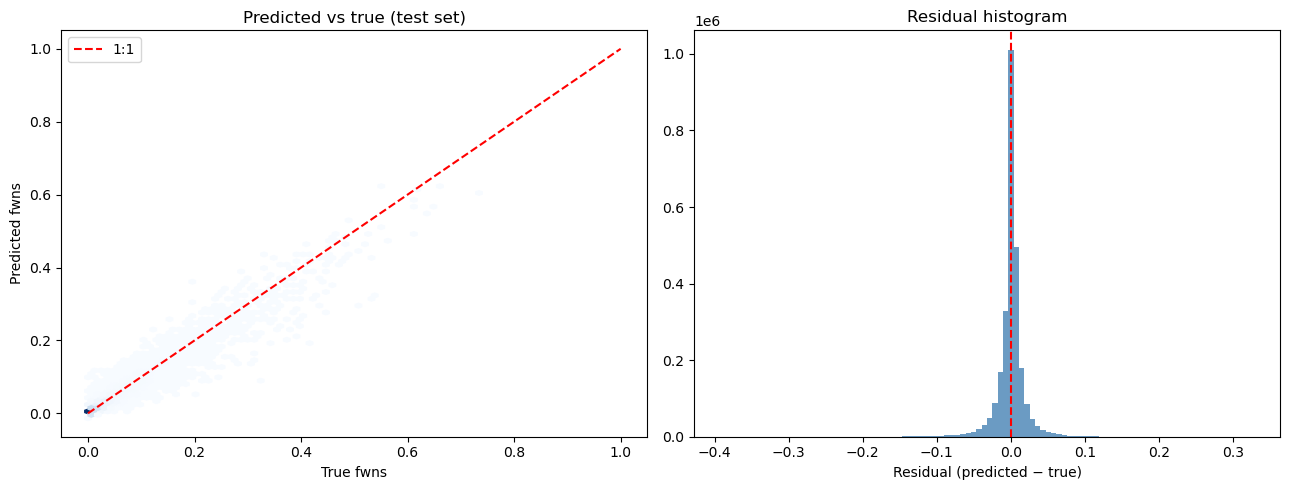

In [ ]:
# Predictions on canonical test set for error analysis
X_err_test = df_model.loc[test_idx, FINAL_FEATURE_SET]
y_err_true = y.loc[test_idx]
y_err_pred = final_model.predict(X_err_test)
residuals = y_err_pred - y_err_true.values

# Scatter predicted vs true with 2D density colouring
# Diagonal concentration = good predictions; vertical spread = high variance regime
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sample_n = min(10000, len(y_err_true))
idx_s = np.random.choice(len(y_err_true), size=sample_n, replace=False)

axes[0].hexbin(y_err_true.values[idx_s], y_err_pred[idx_s],
               gridsize=60, cmap='Blues', mincnt=1)
axes[0].plot([0, 1], [0, 1], 'r--', label='1:1')
axes[0].set_xlabel('True fwns')
axes[0].set_ylabel('Predicted fwns')
axes[0].set_title('Predicted vs true (test set)')
axes[0].legend()

# Residual histogram: look for symmetry and fat tails
axes[1].hist(residuals, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (predicted − true)')
axes[1].set_title('Residual histogram')
plt.tight_layout()
plt.show()

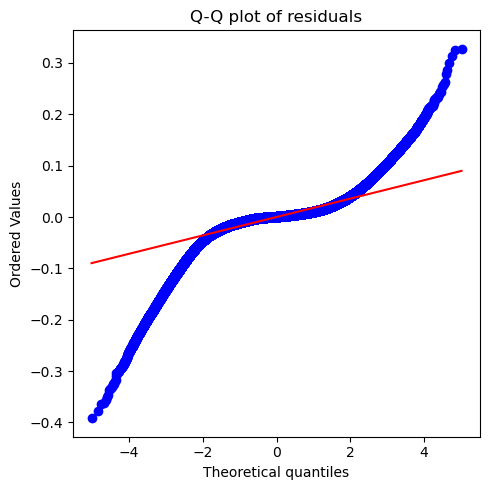

In [ ]:
# Q-Q plot: if residuals are Gaussian the points fall on the diagonal;
# curved tails indicate heavy-tailed or skewed errors
from scipy.stats import probplot
fig, ax = plt.subplots(figsize=(5, 5))
probplot(residuals, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals')
plt.tight_layout()
plt.show()

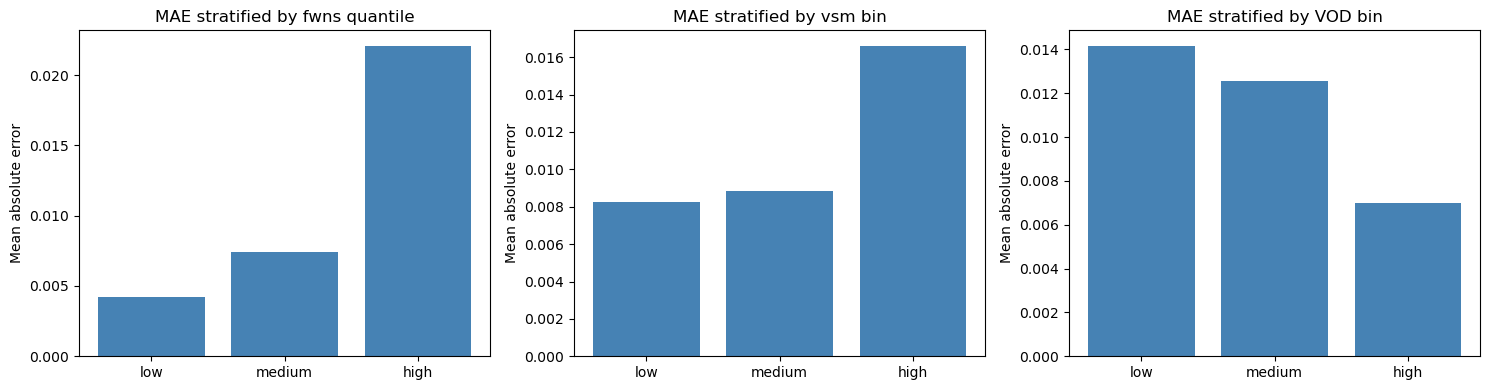

In [ ]:
# Stratified residuals by fwns quantile, vsm, and VOD
# High MAE in specific strata points to regime-dependent model weaknesses
err_df = pd.DataFrame({
    'true': y_err_true.values,
    'pred': y_err_pred,
    'abs_error': np.abs(residuals),
}, index=test_idx)
err_df['vsm'] = df_raw.loc[test_idx, 'vsm'].values
err_df['VOD'] = df_raw.loc[test_idx, 'VOD'].values

err_df['fwns_bin'] = pd.qcut(err_df['true'], q=3, labels=['low', 'medium', 'high'])
err_df['vsm_bin']  = pd.qcut(err_df['vsm'],  q=3, labels=['low', 'medium', 'high'])
err_df['vod_bin']  = pd.qcut(err_df['VOD'],  q=3, labels=['low', 'medium', 'high'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                           ['fwns_bin', 'vsm_bin', 'vod_bin'],
                           ['fwns quantile', 'vsm bin', 'VOD bin']):
    grp = err_df.groupby(col, observed=True)['abs_error'].mean()
    ax.bar(grp.index.astype(str), grp.values, color='steelblue')
    ax.set_ylabel('Mean absolute error')
    ax.set_title(f'MAE stratified by {title}')
plt.tight_layout()
plt.show()

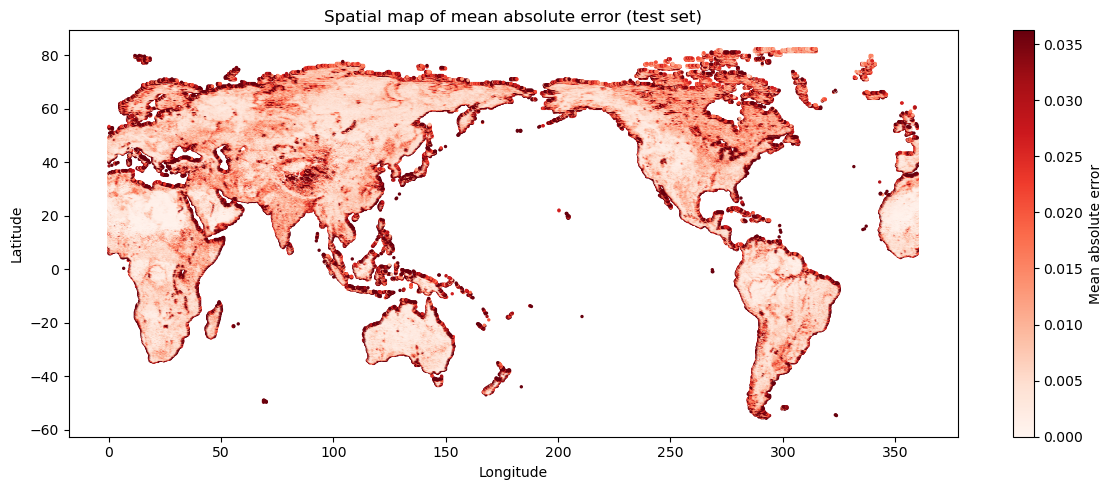

In [ ]:
# Spatial map of mean absolute error per grid cell
# Dense red regions indicate systematic spatial biases
err_df['lat'] = df_raw.loc[test_idx, 'latitude_grid'].values
err_df['lon'] = df_raw.loc[test_idx, 'longitude_grid'].values
spatial_mae = err_df.groupby(['lat', 'lon'])['abs_error'].mean().reset_index()

plt.figure(figsize=(12, 5))
sc = plt.scatter(
    spatial_mae['lon'], spatial_mae['lat'],
    c=spatial_mae['abs_error'], cmap='Reds', s=2, vmin=0, vmax=spatial_mae['abs_error'].quantile(0.95)
)
plt.colorbar(sc, label='Mean absolute error')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial map of mean absolute error (test set)')
plt.tight_layout()
plt.show()

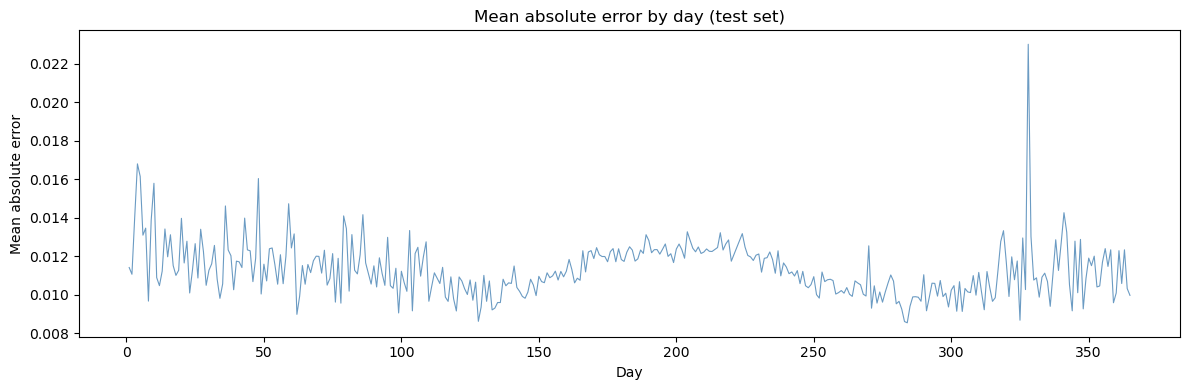

In [ ]:
# Temporal plot: mean absolute error by day
# A trend or seasonality in error suggests temporal non-stationarity
err_df['day'] = df_raw.loc[test_idx, 'day'].values
temporal_mae = err_df.groupby('day')['abs_error'].mean().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(temporal_mae['day'], temporal_mae['abs_error'],
         linewidth=0.8, color='steelblue', alpha=0.8)
plt.xlabel('Day')
plt.ylabel('Mean absolute error')
plt.title('Mean absolute error by day (test set)')
plt.tight_layout()
plt.show()

## 11. Final Model Summary

Retrain the final model on the **complete** dataset (train + test) using OPTIMIZED_PARAMS and FINAL_FEATURE_SET, then perform a final generalisation check. A consolidated three-tier comparison table reports physics baseline, optimized XGBoost (Section 6), and final full-data model. The trained booster is saved to disk.

- **Feature set used:** `FINAL_FEATURE_SET`
- **Model used:** XGBoost with `OPTIMIZED_PARAMS`; trained on full dataset (no held-out test)
- **Why:** final deployment model should use all available labelled data; the generalisation   check with structured splits confirms the model does not degrade from the full-data fit.

In [ ]:
# Retrain on the full dataset (train + test combined)
X_full = df_model[FINAL_FEATURE_SET]
y_full = y

final_model_fulldata = XGBRegressor(**{k: v for k, v in OPTIMIZED_PARAMS.items()
                                       if k not in ('objective', 'eval_metric', 'tree_method')})
final_model_fulldata.fit(X_full, y_full)
print('Retrained final model on full dataset.')
print(f'Full dataset size: {len(X_full):,} rows, {len(FINAL_FEATURE_SET)} features')

Retrained final model on full dataset.
Full dataset size: 13,225,757 rows, 15 features


In [ ]:
# Final generalisation check on structured splits using full-data model
gen_rows = []
for split_name, tr_idx_s, te_idx_s in [
    ('temporal', train_idx_time, test_idx_time),
    ('geographic_corner', train_idx_corner, test_idx_corner),
    ('geographic_block', train_idx_block, test_idx_block),
]:
    X_te_s = df_model.loc[te_idx_s, FINAL_FEATURE_SET]
    y_te_s = y.loc[te_idx_s]
    y_pred_s = final_model_fulldata.predict(X_te_s)
    gen_rows.append({
        'split': split_name,
        'MAE_test':  mean_absolute_error(y_te_s, y_pred_s),
        'RMSE_test': root_mean_squared_error(y_te_s, y_pred_s),
        'R2_test':   r2_score(y_te_s, y_pred_s),
    })

display(pd.DataFrame(gen_rows).round(6))

In [ ]:
# Consolidated comparison table across all three model tiers
# Look for monotonic improvement from physics baseline → reference XGBoost → optimized

# XGBoost reference config on BEST_FEATURE_SET (from Section 5a results)
ref_row = feature_ranking[
    (feature_ranking['model'] == 'XGBoost') &
    (feature_ranking['feature_set'] == BEST_FEATURE_SET_NAME)
].iloc[0]

final_r2_test = r2_score(
    y.loc[test_idx],
    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET])
)
final_mae_test = mean_absolute_error(
    y.loc[test_idx],
    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET])
)
final_rmse_test = root_mean_squared_error(
    y.loc[test_idx],
    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET])
)

summary_table = pd.DataFrame([
    {
        'model_tier': 'Physics baseline (DR)',
        'MAE_test':  physics_baseline_metrics['MAE'],
        'RMSE_test': physics_baseline_metrics['RMSE'],
        'R2_test':   physics_baseline_metrics['R2'],
    },
    {
        'model_tier': 'XGBoost (reference config)',
        'MAE_test':  ref_row['MAE_test'],
        'RMSE_test': np.sqrt(ref_row['MSE_test']),
        'R2_test':   ref_row['R2_test'],
    },
    {
        'model_tier': 'XGBoost (optimized)',
        'MAE_test':  mean_absolute_error(y.loc[test_idx],
                         optimized_model.predict(X_selected_test)),
        'RMSE_test': root_mean_squared_error(y.loc[test_idx],
                         optimized_model.predict(X_selected_test)),
        'R2_test':   r2_score(y.loc[test_idx],
                         optimized_model.predict(X_selected_test)),
    },
    {
        'model_tier': 'XGBoost (final, full data)',
        'MAE_test':  final_mae_test,
        'RMSE_test': final_rmse_test,
        'R2_test':   final_r2_test,
    },
])
display(summary_table.round(6))

,model_tier,MAE_test,RMSE_test,R2_test
0,Physics baseline (DR),0.033409,0.052425,0.495512
1,XGBoost (reference config),0.011493,0.019782,0.928329
2,XGBoost (optimized),0.011013,0.020005,0.926701
3,"XGBoost (final, full data)",0.011238,0.020296,0.924554


In [ ]:
# Save final model booster to disk
final_model_fulldata.get_booster().save_model(f'{MODEL_DIR}/final_model_fulldata.json')
print('Saved: final_model_fulldata.json')

Saved: final_model_fulldata.json


In [ ]:
# Pipeline summary — final cell
r2 = final_r2_test
print(
    f'Pipeline complete. Final feature set: {len(FINAL_FEATURE_SET)} features. '
    f'Final test R\u00b2: {r2:.4f}. Model saved to final_model_fulldata.json.'
)

Pipeline complete. Final feature set: 15 features. Final test R²: 0.9246. Model saved to final_model_fulldata.json.
